# <a href="https://thetahat.ru/courses/ad" target="_top">Введение в анализ данных</a>
## Домашнее задание 9. Статистика и байесовские классификаторы.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко.
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `...`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.



**Баллы за задание:**

* Задача 3 &mdash; 30 баллов
* Задача 4 &mdash; 30 баллов
* Задача 3 &mdash; 50 баллов
* Задача 4 &mdash; 40 баллов

Баллы учитываются в <b><font color="green">факультативной части</font></b> курса и не влияют на оценку по основной части.

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 22.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups

import scipy.stats as sps
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score
import torch
print("Доступен GPU:", torch.cuda.is_available())
print("Название GPU:", torch.cuda.get_device_name(0))
import torch, accelerate, transformers

sns.set(palette='Set2')

Доступен GPU: True
Название GPU: Tesla T4


---
### Задача 1.   
---

**a).** Пусть $X_1,...,X_n$ выборка из некоторого распределения $\mathsf{P}$, причем ${\sf D} X_1=\sigma^2<+\infty$, и $\sigma$ неизвестно.
Рассмотрим оценку $S^2 = \overline{X^2}-\overline{X}^2$ дисперсии $\sigma^2$.

Докажите, что $S^2=\frac1n\sum\limits_{i=1}^n\left(X_i-\overline{X}\right)^2$.

**b).** Оценка $\widehat{\theta}$ называется несмещенной оценкой параметра $\theta$ если для любого $\theta \in \Theta$ выполнено $\mathsf{E}_\theta \widehat{\theta} = \theta$. Иначе говоря, какое бы ни оказалось истинное значение параметра $\theta$, рассматривая оценку $\widehat{\theta}$ в среднем будем получать именно $\theta$.

Является ли статистика $S^2$ несмещенной оценкой $\sigma^2$?

*Подсказка.* Посчитайте математическое ожидание случайной величины $S^2$. Используйте для этого известные вам свойства математического ожидания.

$\textbf{Ответ:}$

$\textbf{a).} Докажем, что  S^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \overline{X})^2 :$

1. Раскроем квадрат:
$$
\sum_{i=1}^n (X_i - \overline{X})^2 = \sum_{i=1}^n \left( X_i^2 - 2X_i\overline{X} + \overline{X}^2 \right).
$$

2. Разделим сумму:
$$
\sum_{i=1}^n X_i^2 - 2\overline{X}\sum_{i=1}^n X_i + n\overline{X}^2.
$$

3. Упростим слагаемые:
$$
\sum_{i=1}^n X_i^2 - 2n\overline{X}^2 + n\overline{X}^2 = \sum_{i=1}^n X_i^2 - n\overline{X}^2.
$$

4. Поделим на $ n $:
$$
\frac{1}{n}\sum_{i=1}^n (X_i - \overline{X})^2 = \frac{1}{n}\sum_{i=1}^n X_i^2 - \overline{X}^2.
$$

5. Сравним с определением $ S^2 $:
$$
S^2 = \overline{X^2} - \overline{X}^2 = \frac{1}{n}\sum_{i=1}^n X_i^2 - \overline{X}^2.
$$

Таким образом, $ S^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \overline{X})^2 $.

$\textbf{b).}$ Проверим несмещённость  $S^2$ :

1. Математическое ожидание $ S^2 $:
$$
\mathbb{E}[S^2] = \mathbb{E}\left[ \frac{1}{n}\sum_{i=1}^n X_i^2 - \overline{X}^2 \right].
$$

2. Разложим на два слагаемых:
$$
= \frac{1}{n}\sum_{i=1}^n \mathbb{E}[X_i^2] - \mathbb{E}\left[\left( \frac{1}{n}\sum_{i=1}^n X_i \right)^2 \right].
$$

3. Упростим первое слагаемое:
$$
\frac{1}{n} \cdot n \cdot \mathbb{E}[X_1^2] = \mathbb{E}[X_1^2].
$$

4. Упростим второе слагаемое, учитывая что
$$
\mathbb{E}[\overline{X}^2] = \mathbb{E}\left[\left(\frac{1}{n}\sum_{i=1}^n X_i\right)^2\right] = \frac{1}{n^2} \mathbb{E}\left[\sum_{i=1}^n X_i^2 + \sum_{i \neq j} X_i X_j\right] = \frac{1}{n} \mathbb{E}[X_1^2] + \frac{n-1}{n} \mu^2 = \frac{\sigma^2 + \mu^2}{n} + \frac{(n-1)\mu^2}{n} = \frac{\sigma^2}{n} + \mu^2.
$$
$$
\mathbb{E}\left[\overline{X}^2\right] = \frac{\sigma^2 + n\mu^2}{n}.
$$

5. Подставим результаты:
$$
\mathbb{E}[S^2] = \mathbb{E}[X_1^2] - \left( \frac{\sigma^2}{n} + \mu^2 \right) = \sigma^2 + \mu^2 - \frac{\sigma^2}{n} - \mu^2 = \sigma^2 \left(1 - \frac{1}{n}\right).
$$

6. Итог:
$$
\mathbb{E}[S^2] = \frac{n-1}{n} \sigma^2 \neq \sigma^2.
$$

$\textbf{Вывод:}$  $S^2$  — смещённая оценка $\sigma^2$.

 ---
### Задача 2.   
---
Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $\mathcal{N}(0, \sigma^2)$. В качестве оценок $\sigma^2$ обычно используют $S^2$ или $\frac{n}{n-1}S^2$. Что можно сказать про их несмещенность?

**Ответ:** $S^2$ является смещённой оценкой.

$\frac{n}{n-1} S^2$ является несмещённой оценкой. Из первой задачи видно, что  условие несмещённости выполняется:
$$
\mathbb{E}[\frac{n}{n-1} S^2] = \frac{n}{n - 1} \mathbb{D}[X_1 \frac{n - 1}{n}] = \mathbb{D}[X_1]
$$

**1.** Теперь проверьте это на практике. Для каждой из приведенных выше оценок $\widehat{\theta}$ выполните следующие действия.

* Вычислите $k = 500$ независимых оценок $\widehat{\theta}_1, ... , \widehat{\theta}_k$ по независимым выборкам $(X_1^1, ... , X_n^1), ... , (X_1^k, ... , X_n^k)$, сгенерированным из распределения $\mathcal{N}(0, \sigma^2)$. Для генерации выберите какое-то истинное значение $\sigma$. Далее вычислите среднее этих оценок, которое обозначим $\widetilde{\theta}$.

* Визуализируйте полученные значения, построив на **одном** графике точки $(\widehat{\theta}_1, y)$, ... , $(\widehat{\theta}_k, y)$ и среднее оценок $(\widetilde{\theta}, y)$, где $y$ &mdash; произвольные различные (например, 0 и 1) координаты для двух различных типов оценок.

* Повторите действие три раза для $n \in \{10, 100, 500\}$. В итоге получится три графика для различных $n$, на каждом из которых изображено поведение двух типов оценок и их среднее.

Используйте приведенный ниже **шаблон** для визуализации значений.

**Внимание!** Следите за информативностью и наглядностью графиков. Например, пустых пространств должно быть как можно меньше, ничего не должно быть скомкано, вся нужная информация должна быть представлена. Посмотрите <a href="https://thetahat.ru/files/ad/main/2/design_hw.pdf"  target="_top">презентацию</a> по оформлению домашних заданий. **Если график чему-то не удовлетворяет, оценка будет снижена.**


In [ ]:
# Вначале:
plt.figure(figsize=<размер>)

# Для каждой оценки:
# y - номер оценки
plt.scatter(<независимые оценки> , np.zeros(k) + y,
            alpha=0.1, s=100, color=<цвет>, label=<метка>)
plt.scatter(<независимые оценки>.mean(), y, marker='*', s=200,
            color='w', edgecolors='black')

# Для всего графика:
plt.vlines(1, <наименьший y>, <наибольший y>, color='r')
plt.title(f'Размер выборки = {n}')
plt.yticks([])
plt.legend()

SyntaxError: invalid syntax (2315759792.py, line 2)

**Решение:**

Напишем функцию подсчёта оценок $\sigma^2$($S^2$ и $\frac{n}{n-1}S^2$) для выбороки размера n из нормального распределения $\mathcal{N}(0, \sigma^2)$, где $\sigma = 5$:

In [ ]:
def Calculator(n):
    biased_estimates = np.zeros(500)
    unbiased_estimates =np.zeros(500)
    for i in range(500):
      vec = sps.norm.rvs(loc=0, scale=5, size=n)
      biased = np.sum(vec ** 2) / n - (np.sum(vec) / n) ** 2
      biased_estimates[i] = biased
      unbiased_estimates[i] = n * biased / (n - 1)
    return biased_estimates, unbiased_estimates

 n = 10:

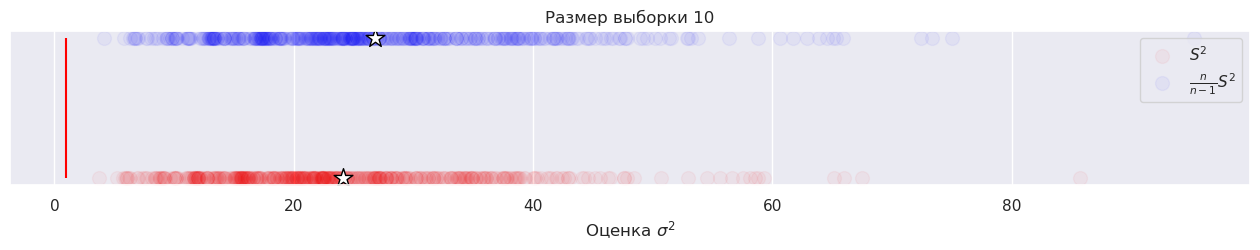

In [ ]:
# Оценки
biased_estimates_10, unbiased_estimates_10 = Calculator(10)

plt.figure(figsize=(16,2))

# Для каждой оценки:
# y - номер оценки
plt.scatter(biased_estimates_10 , np.zeros(500) + 1,
            alpha=0.04, s=100, color="red", label= r'$S^{2}$')
plt.scatter(biased_estimates_10.mean(), 1, marker='*', s=200,
            color='w', edgecolors='black')

plt.scatter(unbiased_estimates_10 , np.zeros(500) + 2,
            alpha=0.04, s=100, color="blue", label= r'$\frac{n}{n-1} S^{2}$')
plt.scatter(unbiased_estimates_10.mean(), 2, marker='*', s=200,
            color='w', edgecolors='black')
# Для всего графика:
plt.vlines(1, 1, 2, color='r')
plt.title(f'Размер выборки {10}')
plt.yticks([])
plt.legend()
plt.xlabel(r"Оценка $\sigma^2$");

Пояснение: звёздочки - это средние оценки

n = 100:

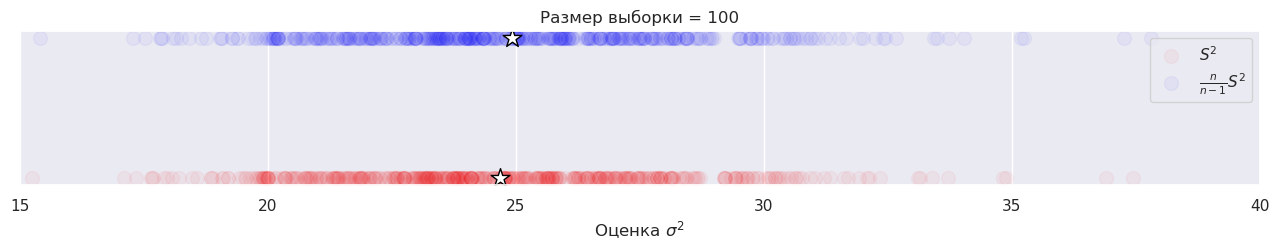

In [ ]:
# Оценки
biased_estimates_100, unbiased_estimates_100 = Calculator(100)

plt.figure(figsize=(16,2))

# Для каждой оценки:
# y - номер оценки
plt.scatter(biased_estimates_100 , np.zeros(500) + 1,
            alpha=0.04, s=100, color="red", label= r'$S^{2}$')
plt.scatter(biased_estimates_100.mean(), 1, marker='*', s=200,
            color='w', edgecolors='black')

plt.scatter(unbiased_estimates_100 , np.zeros(500) + 2,
            alpha=0.04, s=100, color="blue", label= r'$\frac{n}{n-1} S^{2}$')
plt.scatter(unbiased_estimates_100.mean(), 2, marker='*', s=200,
            color='w', edgecolors='black')
# Для всего графика:
plt.vlines(1, 1, 2, color='r')
plt.title(f'Размер выборки = {100}')
plt.yticks([])
plt.legend()
plt.xlim(15, 40)
plt.xlabel(r"Оценка $\sigma^2$");

Пояснение: звёздочки - это средние оценки

n = 500:

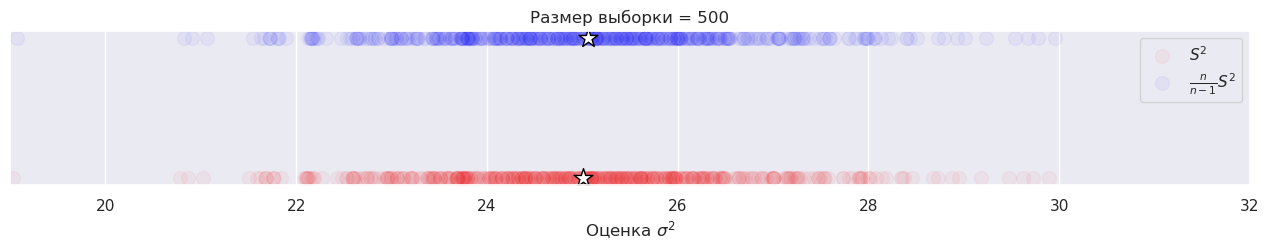

In [ ]:
# Оценки
biased_estimates_500, unbiased_estimates_500 = Calculator(500)

plt.figure(figsize=(16,2))

# Для каждой оценки:
# y - номер оценки
plt.scatter(biased_estimates_500 , np.zeros(500) + 1,
            alpha=0.04, s=100, color="red", label= r'$S^{2}$')
plt.scatter(biased_estimates_500.mean(), 1, marker='*', s=200,
            color='w', edgecolors='black')

plt.scatter(unbiased_estimates_500 , np.zeros(500) + 2,
            alpha=0.04, s=100, color="blue", label= r'$\frac{n}{n-1} S^{2}$')
plt.scatter(unbiased_estimates_500.mean(), 2, marker='*', s=200,
            color='w', edgecolors='black')
# Для всего графика:
plt.vlines(1, 1, 2, color='r')
plt.title(f'Размер выборки = {500}')
plt.yticks([])
plt.legend()
plt.xlim(19, 32)
plt.xlabel(r"Оценка $\sigma^2$");

Пояснение: звёздочки - это средние оценки

**2.** Изучим поведение среднего оценок из первого пункта при росте размера выборки. Постройте график зависимости $\widetilde{\theta}$ от $n$ для двух типов оценок. Для вычисления зависимости нужно один раз сгенерировать выборки из пункта 1 достаточно большого размера (не более 500) и посчитать оценки по подвыборкам, используя <a href="https://thetahat.ru/courses/python/03"  target="_top">функции</a> из `numpy`. Использовать циклы, а так же функции, разворачивающиеся в цикл (например, `np.vectorize`), запрещено.

**Решение:**

Создадим матрицу data размером 500×500, где каждая строка — независимая выборка из $\mathcal{N}(0, 25)$. Для всех n одновременно вычиcлим оценки дисперсии, используя ранее полученные формулы. Усреднение оценок происходит по столбцам.

/tmp/ipykernel_671/1839802238.py:22: RuntimeWarning: divide by zero encountered in divide
  n_factors = np.where(n_values > 1, n_values / (n_values - 1), np.nan)
/tmp/ipykernel_671/1839802238.py:27: RuntimeWarning: Mean of empty slice
  mean_unbiased = np.nanmean(unbiased, axis=0)


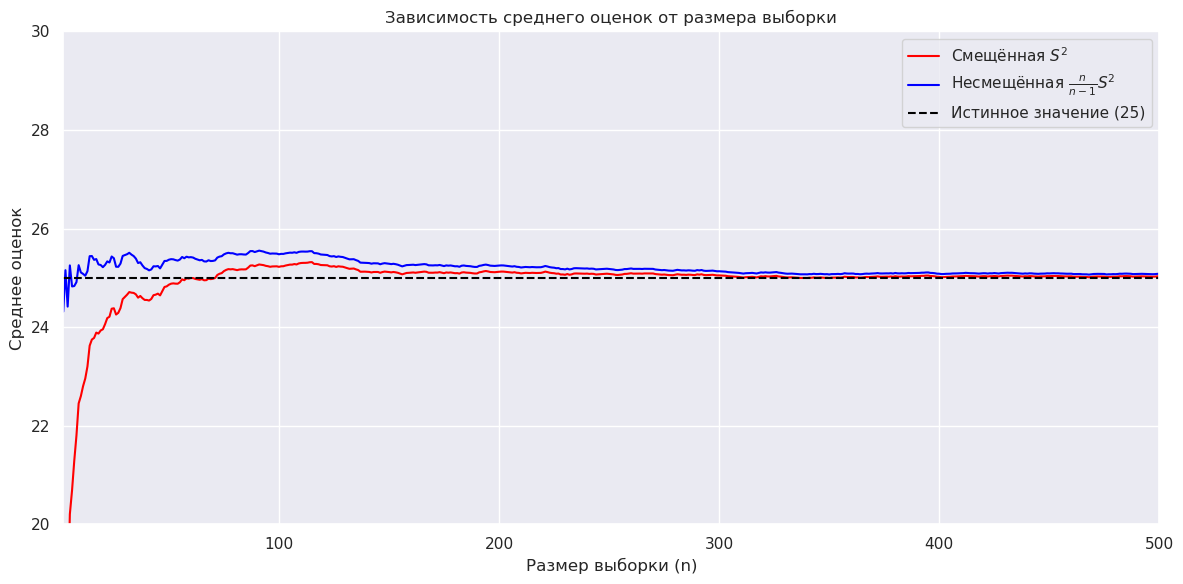

In [ ]:
# Параметры
sigma_true = 5
k = 500      # Количество повторений
N = 500      # Максимальный размер выборки
true_var = sigma_true**2

# Генерируем данные: матрица [k x N] (500 симуляций по 500 наблюдений)
data = sps.norm.rvs(loc=0, scale=sigma_true, size=(k, N))

# Кумулятивные суммы и суммы квадратов
cum_sum = np.cumsum(data, axis=1)
cum_sum_sq = np.cumsum(data**2, axis=1)

# Все возможные размеры выборок n (от 1 до N)
n_values = np.arange(1, N+1)

# Вычисление оценок для всех n одновременно
# Смещенная оценка S^2
biased = (cum_sum_sq / n_values) - (cum_sum / n_values)**2

# Несмещенная оценка (n/(n-1))S^2
n_factors = np.where(n_values > 1, n_values / (n_values - 1), np.nan)
unbiased = biased * n_factors.reshape(1, -1)

# Усреднение
mean_biased = np.nanmean(biased, axis=0)
mean_unbiased = np.nanmean(unbiased, axis=0)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(n_values, mean_biased, color='red', label=r'Смещённая $S^2$')
plt.plot(n_values, mean_unbiased, color='blue', label=r'Несмещённая $\frac{n}{n-1}S^2$')
plt.axhline(true_var, color='black', linestyle='--', label=f'Истинное значение ({true_var})')

plt.xlim(2, N)  # Исключаем n=1 для наглядности
plt.ylim(true_var - 5, true_var + 5)
plt.xlabel('Размер выборки (n)')
plt.ylabel('Среднее оценок')
plt.title('Зависимость среднего оценок от размера выборки')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Сделайте вывод о том, что такое свойство несмещенности. Подтверждают ли сделанные эксперименты полученное в теоретических задачах свойство несмещенности (или отсутствие этого свойства) данных оценок?

*Для ПМФ:* поясните, почему в лабораторных по физике при оценке погрешности иногда используют $n-1$ в знаменателе, а не $n$.

*Замечание.* Для ответа на вопрос достаточно понимания текущего материала, ничего из физики знать не требуется.

**Вывод:**

Из последнего полученного графика можно сделать вывод, что свойство несмещённости позволяет средней оценке держаться около истинного значения параметра при любом размере выборки. Различие между смещённой и несмещённой оценками особенно видно при малом размере выборки.

Сделанные эксперименты подтверждают свойство несмещённости. Действительно видно, что матожидание равно истинному значению при достаточно большой выборке. Однако, это видно и у несмещённой оценки. Но у смещённой оценки при малом размере выборки ни разу не было матожидания около 25.

Из всего вышесказанного можно сделать вывод, что несмещённость, теоретически предсказывающая равенство матожидания, на практике не позволяет средней оценке слишком сильно отклоняться  в зависимости от размера выборк по сравнению со смещённой оценкой.

ПМФ: Если погрешность носит статистический характер, то можно положить, что значения независимы и имеют одинаковое распределение. В таком случае её можно оценить дисперсией, несмещённую оценку которой нужно считать с n-1 в знаменателе.

*Замечание.* Проведенные эксперименты позволяют сделать вывод только о поведении среднего значения оценки, но ничего не говорят о том, насколько велик их разброс относительно среднего.

---
### Задача 3.
---
Рассмотрим задачу построения системы, автоматически классифицирующей поступающие новостные сюжеты на несколько заранее заданных категорий.



Перед выполнением задачи обязательно посмотрите <a href="https://thetahat.ru/courses/ad/main/10/bayes_classification" target="_top">ноутбук</a> с занятия по классификации.

---

С помощью кода ниже загрузите встроенные в `sklearn` <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#sklearn.datasets.fetch_20newsgroups">данные</a>, в которых представлены различные новостные сюжеты, разделенные на 20 тематических групп.

In [ ]:
# удаляем заголовки и подписи
remove = ('headers', 'footers')
# зафиксируем зерно случайности
random_state = 42

# Извлекаем обучающую и тестовую части перемешивая случайным образом
data_train = fetch_20newsgroups(
    subset='train', shuffle=True, random_state=random_state, remove=remove
)
data_test = fetch_20newsgroups(
    subset='test', shuffle=True, random_state=random_state, remove=remove
)

Посмотрим на какое-нибудь сообщение

In [ ]:
print(data_train['data'][21])

In article <1993Apr20.151818.4319@samba.oit.unc.edu> Scott.Marks@launchpad.unc.edu (Scott Marks) writes:
>>And of course, Mike Ramsey was (at one time) the captain in Buffalo prior to
>>being traded to Pittsburgh.  Currently, the Penguins have 3 former captains
>>and 1 real captain (Lemieux) playing for them.  They rotate the A's during the
>>season (and even the C while Mario was out).  Even Troy Loney has worn the C
>>for the Pens.
>

I think that Mike Foligno was the captain of the Sabres when he
got traded to the Leafs. Also, wasn't Rick Vaive the captain of
the Leafs when he got traded to Chicago (with Steve Thomas for
Ed Olcyzk and someone). Speaking of the Leafs, I believe that
Darryl Sittler was their captain (he'd torn the "C" off his
jersey but I think he re-claimed the captaincy later on) when he
was traded to the Flyers.

Oh yeah, of course, Gretzky was the captain of the Oilers before
he was traded wasn't he? 


Индекс тематической группы для каждого сообщения

In [ ]:
data_train['target']

array([7, 4, 4, ..., 3, 1, 8])

Названия тематических групп

In [ ]:
data_train['target_names']

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

Разделите данные на обучающую, валидационную и тестовую части

In [ ]:
# Разделяем обучающие данные на тренировочную и валидационную части (80%/20%)
X_train, X_val, y_train, y_val = train_test_split(
    data_train.data,
    data_train.target,
    test_size=0.2,
    random_state=random_state,
    stratify=data_train.target  # Сохраняем распределение классов
)

# Сохраним тестовые данные в отдельные списки
X_test = data_test.data
y_test = data_test.target

# Выводим размеры выборок
print(f"Обучающая выборка: {len(X_train)} примеров")
print(f"Валидационная выборка: {len(X_val)} примеров")
print(f"Тестовая выборка: {len(X_test)} примеров")

Обучающая выборка: 9051 примеров
Валидационная выборка: 2263 примеров
Тестовая выборка: 7532 примеров


Прежде чем приступать к построению сложных систем всегда стоит выбрать простой бейзлайн &mdash; модель, которую вы можете получить относительно быстро, и она не занимает много ресурсов.

В качестве бейзлайна рассмотрим простую модель, обученную на представлении текстов в виде мешка слов (bag of words). Мы можем обучить два известных нам классификатора:
* метод ближайших соседей,
* наивный байесовский классификатор.

Подумайте, почему метод ближайших соседей не подходит для решения данной задачи.

Метод ближайших соседей плохо работает из-за проклятия размерности. У нас размерность (9051, 10000).

Обучите наивный байесовский классификатор, подобрав также для него оптимальные гиперпараметры. В качестве гиперпараметров можно рассмотреть, например, параметры мешка слов.

Для выполнения этой процедуры зафиксируйте несколько комбинаций значений гиперпараметров, для каждой из них обучите модель по обучающей части выборки и посчитайте качество (точность классификации) на валидационной части. Выберите классификатор, дающий максимальную точность.

In [ ]:
# Пробуем 3 комбинации гиперпараметров
params_combinations = [
    {
        'max_features': 5000,
        'ngram_range': (1, 1),
        'alpha': 1.0
    },
    {
        'max_features': 10000,
        'ngram_range': (1, 2),
        'alpha': 0.1
    },
    {
        'max_features': 15000,
        'ngram_range': (1, 1),
        'alpha': 0.5
    }
]

In [ ]:
best_score = 0
best_params = None

for params in params_combinations:
    # Векторизация текста
    tfidf = TfidfVectorizer(
        max_features=params['max_features'],
        ngram_range=params['ngram_range']
    )
    X_train_vec = tfidf.fit_transform(X_train)
    X_val_vec = tfidf.transform(X_val)

    # Обучение модели
    model = MultinomialNB(alpha=params['alpha'])
    model.fit(X_train_vec, y_train)

    # Оценка на валидации
    val_pred = model.predict(X_val_vec)
    score = accuracy_score(y_val, val_pred)

    print(f"Параметры: {params}")
    print(f"Точность: {score:.3}\n")

    # Сохраняем лучший результат
    if score > best_score:
        best_score = score
        best_params = params

Параметры: {'max_features': 5000, 'ngram_range': (1, 1), 'alpha': 1.0}
Точность: 0.786

Параметры: {'max_features': 10000, 'ngram_range': (1, 2), 'alpha': 0.1}
Точность: 0.817

Параметры: {'max_features': 15000, 'ngram_range': (1, 1), 'alpha': 0.5}
Точность: 0.832



Посчитайте качество на тестовой выборке.

In [ ]:
print("Лучшие параметры:", best_params)
print("Лучшая точность:", best_score)

Лучшие параметры: {'max_features': 15000, 'ngram_range': (1, 1), 'alpha': 0.5}
Лучшая точность: 0.831639416703491


Выберите некоторую нейросеть для классификации текстов. Вы можете выбрать готовую нейросеть и дообучить ее на рассматриваемых данных, как это сделано на <a href="https://thetahat.ru/courses/ad/main/10/bayes_classification"  target="_top">семинаре</a>, так и самостоятельно написать нейросеть.

Выберем DistilBERT.

In [ ]:
# Подготовка данных в формате HuggingFace Dataset
train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
val_dataset = Dataset.from_dict({"text": X_val, "label": y_val})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

In [ ]:
# Загрузка токенизатора и токенизация данных
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=256  # Оптимально для новостных текстов
    )

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True, batch_size=64)
val_dataset = val_dataset.map(tokenize, batched=True, batch_size=64)
test_dataset = test_dataset.map(tokenize, batched=True, batch_size=64)

Map:   0%|          | 0/9051 [00:00<?, ? examples/s]

Map:   0%|          | 0/2263 [00:00<?, ? examples/s]

Map:   0%|          | 0/7532 [00:00<?, ? examples/s]

In [ ]:
# Создание модели
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=20,
    id2label={i: name for i, name in enumerate(data_train.target_names)}
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
print(f"PyTorch: {torch.__version__}")
print(f"Accelerate: {accelerate.__version__}")
print(f"Transformers: {transformers.__version__}")

PyTorch: 2.6.0+cu124
Accelerate: 1.6.0
Transformers: 4.51.3


In [ ]:
# Настройка обучения
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    eval_strategy="steps",
    eval_steps=500,
    logging_steps=100,
    fp16=True,
    optim="adamw_torch_fused",
    report_to="none",
    save_total_limit=1
)

In [ ]:
# Функция вычисления метрик
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds)}

In [ ]:
# Обучение
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss,Validation Loss


TrainOutput(global_step=282, training_loss=1.169830728084483, metrics={'train_runtime': 103.582, 'train_samples_per_second': 174.76, 'train_steps_per_second': 2.722, 'total_flos': 1193318096087040.0, 'train_loss': 1.169830728084483, 'epoch': 1.989399293286219})

Сравните качество моделей на тестовой выборке. Можно ли с уверенностью утверждать, что одна из моделей лучше другой?

In [ ]:
# Оценка на тестовой выборке
test_results = trainer.evaluate(test_dataset)
print(f"Точность на тестовой выборке: {test_results['eval_accuracy']:.3f}")

Точность на тестовой выборке: 0.749


Точность первой модели с наилучими парамтерами больше. Разница в точности ~8% (83.1% vs 74.9%) достаточно велика, чтобы утверждать, что наивный Байес с выбранными параметрами значительно превосходит DistilBERT на данном датасете.

Сделайте выводы.

Новостные сюжеты часто содержат четкие тематические маркеры (например, слова "хоккей", "процессор", "религия"), которые хорошо захватываются мешком слов.

DistilBERT, возможно, требует более тонкой настройки

Наивный Байес показывает лучшее качество при минимальных ресурсах.

В заключение, классическая ML-модель превзошла нейросетевой подход. Это демонстрирует, что для узких задач с четкими признаками "простота vs сложность" не всегда коррелирует с качеством.

P.S. Нужно снести винду. А то у меня wsl и vscode работать перестали из-за новых библиотек и отсутствия места на диске. (ну и намучился)

---
### Задача 4.
---

Пусть $\mathscr{X} = \mathbb{R}^d$ — пространство признаков, $\mathscr{Y} = \{0, 1\}$ — множество классов. Рассматривается квадратичный дискриминантный анализ (QDA), в котором условное распределение $X$ при условии $Y=k$ равно $\mathcal{N}(a_k, \Sigma_k)$. Разделяющей поверхностью между классами $k$ и $\ell$ называется множество точек пространства признаков, для которых вероятность этих двух классов одинакова.

**1.**
Покажите, что в модели QDA разделяющие поверхности в общем случае квадратичны, а в LDA &mdash; линейны между любыми двумя классами.

*Примечание.* В LDA предполагается $\Sigma_1 = ... = \Sigma_k$.

**2.**
Рассмотрим квадратичный дискриминантный анализ при $d=2$. Приведите примеры таких параметров $a_k, \Sigma_k$ и вероятностей $\mathsf{P}(Y = k)$, при которых разделяющая поверхность является
* гиперболой;
* параболой;
* двумя параллельными прямыми;
* двумя пересекающимися прямыми.

*Примечание.* Можно подобрать выборку, посчитать оценки со страшными числами. Но еще лучше &mdash; немного подумать и привести пример с "красивыми" числами без какого-либо подбора выборки. В данном случае это довольно просто, а также позволяет лучше разобраться в параметрах многомерного нормального распределения.


$\textbf{1.}$ **Разделяющие поверхности в QDA и LDA**

1. **Условие равенства апостериорных вероятностей:**
   \begin{align*}
   P(Y=k|X=x) = P(Y=\ell|X=x)
   \end{align*}

2. **Применяем формулу Байеса:**
   \begin{align*}
   \frac{\pi_k \cdot \mathcal{N}(x|a_k, \Sigma_k)}{\pi_\ell \cdot \mathcal{N}(x|a_\ell, \Sigma_\ell)} = 1
   \end{align*}

3. **Логарифмируем и подставляем плотности:**
   \begin{align*}
   \ln\frac{\pi_k}{\pi_\ell} - \frac{1}{2}\left(
   \ln|\Sigma_k| - \ln|\Sigma_\ell| + (x-a_k)^\top\Sigma_k^{-1}(x-a_k) - (x-a_\ell)^\top\Sigma_\ell^{-1}(x-a_\ell)
   \right) = 0
   \end{align*}

4. **Раскрываем квадратичные формы:**
   \begin{align*}
   (x-a_k)^\top\Sigma_k^{-1}(x-a_k) = x^\top\Sigma_k^{-1}x - 2a_k^\top\Sigma_k^{-1}x + a_k^\top\Sigma_k^{-1}a_k
   \end{align*}

5. **Собираем слагаемые:**
   \begin{align*}
   x^\top(\Sigma_k^{-1}-\Sigma_\ell^{-1})x + 2x^\top(\Sigma_\ell^{-1}a_\ell - \Sigma_k^{-1}a_k) + C = 0
   \end{align*}

   - Для **QDA** ($\Sigma_k \neq \Sigma_\ell$): квадратичное уравнение $\Rightarrow$ поверхность второго порядка.
   - Для **LDA** ($\Sigma_k = \Sigma_\ell$): квадратичные члены исчезают $\Rightarrow$ линейное уравнение.

$\textbf{2.}$ **Примеры для QDA**

$\textbf{a) Гипербола:}$
- Параметры:
  - $a_0 = (2,0),\ a_1 = (0,0)$
  - $\Sigma_0 = I,\ \Sigma_1 = \begin{pmatrix}2&0\\0&0.5\end{pmatrix}$
  - $\pi_0 = \pi_1 = 0.5$

- Уравнение после преобразований:
  \begin{align*}
  \frac{(x_1-2)^2}{1} + x_2^2 - \frac{x_1^2}{2} - 2x_2^2 = C \quad \Rightarrow \quad \frac{x_1^2}{2} - x_2^2 - 4x_1 + 4 = C
  \end{align*}

$\textbf{b) Парабола:}$
- Параметры:
  - $a_0 = (0,0),\ a_1 = (0,1)$
  - $\Sigma_0 = I,\ \Sigma_1 = \begin{pmatrix}2&0\\0&1\end{pmatrix}$
  - $\pi_0 = \pi_1 = 0.5$

- Уравнение после преобразований:
  \begin{align*}
  x_1^2 + x_2^2 - \frac{x_1^2}{2} - (x_2-1)^2 = C \quad \Rightarrow \quad x_1^2 = -4x_2 + C
  \end{align*}

$\textbf{c) Две параллельные прямые:}$
- Параметры:
  - $a_0 = a_1 = (0,0)$
  - $\Sigma_0 = \begin{pmatrix}2&1\\1&2\end{pmatrix},\ \Sigma_1 = I$
  - $\pi_0 = \pi_1 = 0.5$

- Уравнение после преобразований:
  \begin{align*}
  \frac{(x_1+x_2)^2}{3} - \frac{x_1^2+x_2^2}{2} = C \quad \Rightarrow \quad (x_1+x_2)^2 = C
  \end{align*}

$\textbf{d) Две пересекающиеся прямые:}$
- Параметры:
  - $a_0 = a_1 = (0,0)$
  - $\Sigma_0 = \begin{pmatrix}0.5&0\\0&1\end{pmatrix},\ \Sigma_1 = \begin{pmatrix}1&0\\0&0.5\end{pmatrix}$
  - $\pi_0 = \pi_1 = 0.5$

- Уравнение после преобразований:
  \begin{align*}
  2x_1^2 + x_2^2 - x_1^2 - 2x_2^2 = C \quad \Rightarrow \quad x_1^2 - x_2^2 = 0 \quad \Rightarrow \quad x_1 = \pm x_2
  \end{align*}